In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib

SEED = 42

In [3]:
params_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [5]:
fighting_df = pd.read_csv('../../Data/Processed/selected_fighting_features.csv')

print(fighting_df.shape)

(80, 11)


In [6]:
fighting_X = fighting_df.drop('feedback', axis=1)
fighting_y = fighting_df['feedback']

scaler = StandardScaler()
fighting_X_scaled = scaler.fit_transform(fighting_X)

fighting_rf = RandomForestClassifier(random_state=SEED)

grid_search = GridSearchCV(
    estimator=fighting_rf,
    param_grid=params_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(fighting_X_scaled, fighting_y)

print(f"Best parameters: ", grid_search.best_params_)
print(f"Best score: ", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best score:  0.925099595393713


In [7]:
best_params = grid_search.best_params_

final_fighting_model = RandomForestClassifier(**best_params, random_state=SEED)

final_fighting_model.fit(fighting_X_scaled, fighting_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
# Check feature importances
fighting_importances = final_fighting_model.feature_importances_
fighting_feature_names = fighting_X.columns
for name, imp in sorted(zip(fighting_feature_names, fighting_importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")

combatEfficiency: 0.361
damageIntakeRate: 0.169
combatPerformanceIndex: 0.144
damagePerSecond: 0.108
victory: 0.063
comboRate: 0.050
sessionDuration: 0.030
dodgeRate: 0.030
playerAccuracy: 0.026
reactionScore: 0.019


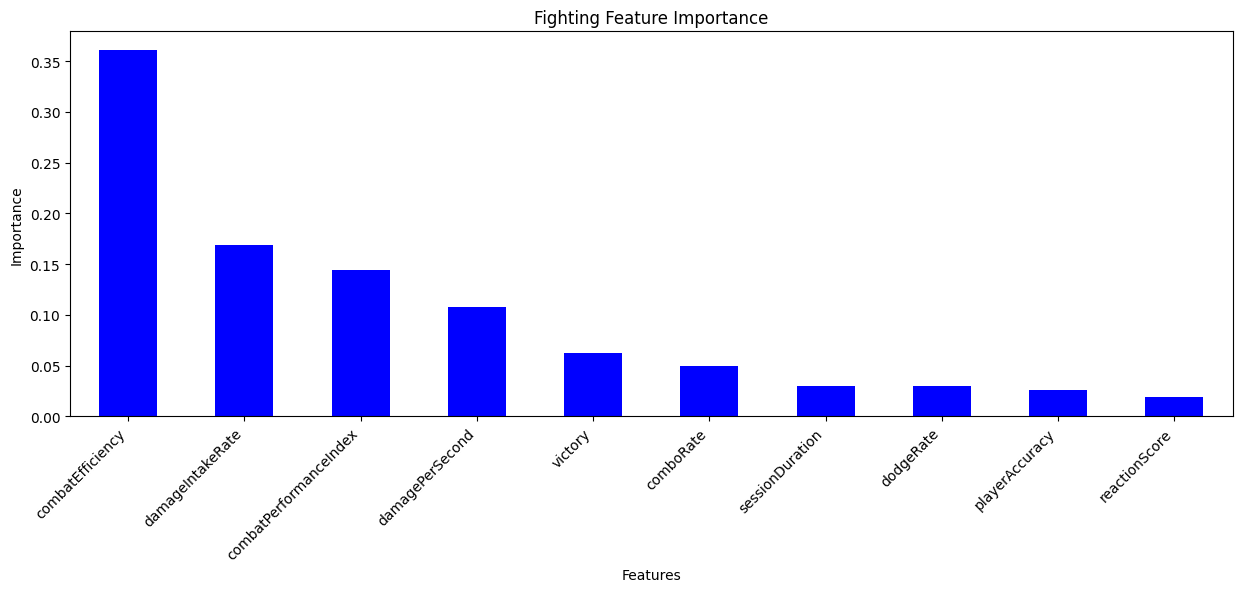

In [9]:
fighting_importance_series = pd.Series(fighting_importances, index=fighting_feature_names)
sorted_fighting_importance = fighting_importance_series.sort_values(ascending=False)

plt.figure(figsize=(15,5))
sorted_fighting_importance.plot(kind='bar', color='blue')
plt.title("Fighting Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [10]:
racing_df = pd.read_csv('../../Data/Processed/selected_racing_features.csv')

print(racing_df.shape)

(80, 9)


In [ ]:
racing_X = racing_df.drop('feedback', axis=1)
racing_y = racing_df['feedback']

racing_X_scaled = scaler.fit_transform(racing_X)

racing_rf = RandomForestClassifier(random_state=SEED)

grid_search = GridSearchCV(
    estimator=racing_rf,
    param_grid=params_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(racing_X_scaled, racing_y)

print(f"Best parameters: ", grid_search.best_params_)
print(f"Best score: ", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best score:  0.9098027898027897


In [12]:
best_params = grid_search.best_params_

final_racing_model = RandomForestClassifier(**best_params, random_state=SEED)

final_racing_model.fit(racing_X_scaled, racing_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# Check feature importances
racing_importances = final_racing_model.feature_importances_
racing_feature_names = racing_X.columns
for name, imp in sorted(zip(racing_feature_names, racing_importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")

collisionRate: 0.253
cleanRacingScore: 0.246
drivingSmoothness: 0.236
racingPerformanceIndex: 0.143
speedEfficiency: 0.066
consistency: 0.026
timeEfficiency: 0.017
lapsCompleted: 0.013


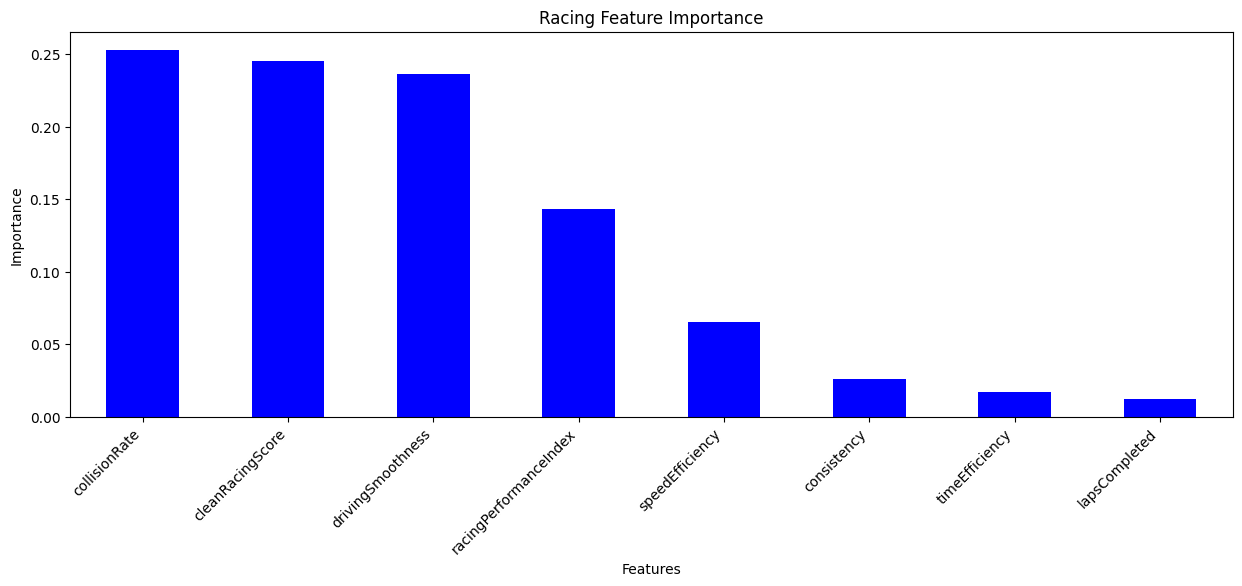

In [14]:
racing_importance_series = pd.Series(racing_importances, index=racing_feature_names)
sorted_racing_importance = racing_importance_series.sort_values(ascending=False)

plt.figure(figsize=(15,5))
sorted_racing_importance.plot(kind='bar', color='blue')
plt.title("Racing Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [17]:
joblib.dump(final_fighting_model, r'C:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\Assets\Models\fighting_model.pkl')
joblib.dump(final_racing_model, r'C:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\Assets\Models\racing_model.pkl')
joblib.dump(scaler, r'C:\Users\Admin\Documents\FYP - Metaverse for Virtual Game\Assets\Models\scaler.pkl')

['C:\\Users\\Admin\\Documents\\FYP - Metaverse for Virtual Game\\Assets\\Models\\scaler.pkl']